![](https://www.rmg.co.uk/sites/default/files/styles/full_width_2600/public/Atlantic%20liner%20%27Titanic%27%20%28Br%2C%201912%29%20sinking%2C%20bow%20first%2C%201912%2C%20with%20eight%20full%20lifeboats%20nearby%20and%20an%20iceberg%20in%20the%20distance_banner.jpg?itok=AvBc7Sno)

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
plt.figure(figsize=(10,10))
sns.set_style('darkgrid')
pd.set_option('display.max_rows',100)
warnings.filterwarnings('ignore')

<Figure size 720x720 with 0 Axes>

# Load Data

In [2]:
titanic_data = pd.read_csv('../input/titanic/train.csv', index_col='PassengerId')
titanic_test = pd.read_csv('../input/titanic/test.csv', index_col='PassengerId')
titanic_Ytest = pd.read_csv('../input/titanic/gender_submission.csv', index_col='PassengerId')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


> **Lets consider the (survived) feature in test data with (2 as unknown) to use test data “without test result” for exploring, understaning, filling null values and rescalling only**

In [3]:
titanic_test['Survived']=2
titanic= pd.concat([titanic_data,titanic_test])
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1305,2,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,2,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,2,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


0    549
1    342
2    418
Name: Survived, dtype: int64

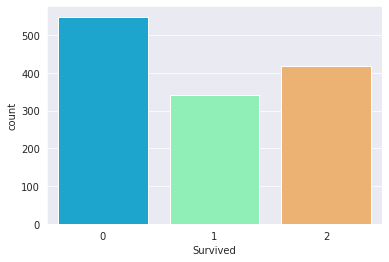

In [4]:
sns.countplot(data=titanic, x='Survived', palette='rainbow')
titanic.Survived.value_counts().sort_index()

> **Train data have unbalanced "survived" data and test data is almost one third of whole data.**

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 1 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1309 non-null   int64  
 1   Pclass    1309 non-null   int64  
 2   Name      1309 non-null   object 
 3   Sex       1309 non-null   object 
 4   Age       1046 non-null   float64
 5   SibSp     1309 non-null   int64  
 6   Parch     1309 non-null   int64  
 7   Ticket    1309 non-null   object 
 8   Fare      1308 non-null   float64
 9   Cabin     295 non-null    object 
 10  Embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 155.0+ KB


## Lets check for null values

In [6]:
titanic_na = (titanic.isna().sum()).to_frame(name='Train_na')
titanic_na

,Train_na
Survived,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


Text(0.5, 1.0, 'count missing values')

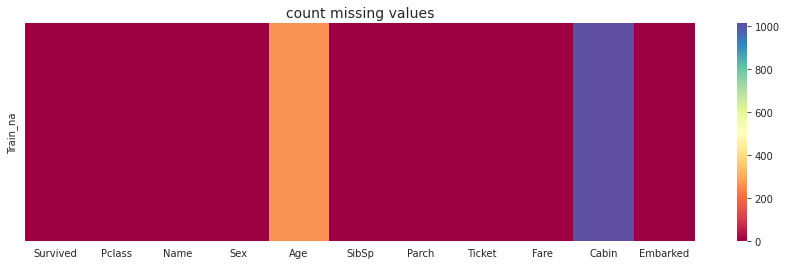

In [7]:
plt.figure(figsize=(15,4))
sns.heatmap(data=titanic_na.T,cmap='Spectral').set_title('count missing values', fontsize=14)

> **It looks like some passengers couldn't complete their information. Maybe they didn't survive? Let's check.**

In [8]:
titanic['NaCount'] = titanic.T.isna().sum()
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,NaCount
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,2
1306,2,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
1307,2,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1


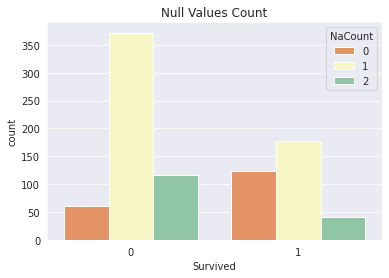

In [9]:
sns.countplot(data=titanic[titanic.Survived!=2], x='Survived', hue='NaCount',palette='Spectral').set_title('Null Values Count')
plt.show()

> **Yes, the unsurvived passengers have more incomplete data than surviving passengers. So, we can consider this as a criterion.**

# Exploring Data

### Let's check for missing 'Embarked' and remove 'Cabin' data. Most of it is missing, so it is not useful.

In [10]:
titanic[titanic.Embarked.isna()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,NaCount
PassengerId,,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1


> **Impute by Embarked Mode**

In [11]:
titanic.Embarked.fillna(titanic.Embarked.mode()[0],inplace=True)
titanic.drop(columns='Cabin', axis=1, inplace=True)
titanic.Embarked = titanic['Embarked'].astype('category')

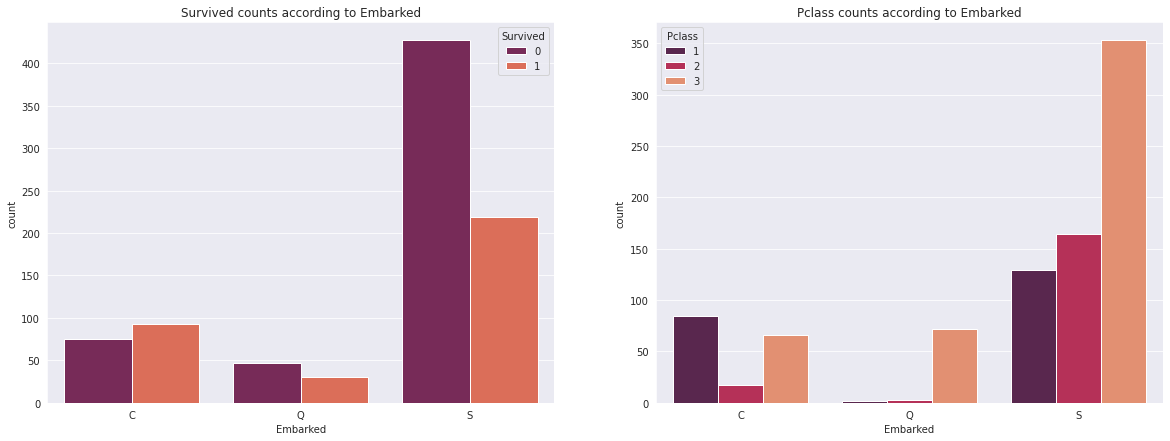

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(20,7))
sns.countplot(data=titanic[titanic.Survived!=2] ,x='Embarked', hue='Survived', palette='rocket', ax=ax[0]).set_title('Survived counts according to Embarked')
sns.countplot(data=titanic[titanic.Survived!=2] ,x='Embarked', hue='Pclass', palette='rocket', ax=ax[1]).set_title('Pclass counts according to Embarked')
plt.show()

> **Most passengers from all classes embarked from Southampton.**

### The name feature is not important, but it contains useful information, which is a prefix. Let's extract it. It is located between the first comma and the dot.

In [13]:
titanic['Prefix'] = titanic.Name.str.split(',').str[1].str.split('.').str[0].str.strip()
titles = titanic.Prefix.value_counts().to_frame()
titles.reset_index(inplace=True)
titles.columns=['Prefix','Nums']
titles.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
Prefix,Mr,Miss,Mrs,Master,Rev,Dr,Col,Mlle,Major,Ms,Lady,Sir,Mme,Don,Capt,the Countess,Jonkheer,Dona
Nums,757,260,197,61,8,8,4,2,2,2,1,1,1,1,1,1,1,1


> **Oh, there are 18 different prefixes, but fortunately there are some homogeneous categories, so we can merge them. But let's see the rare titles first.**

In [14]:
titanic[titanic.Prefix.isin(titles[titles.Nums<10]['Prefix'])].sort_values(by='Prefix')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,NaCount,Prefix
PassengerId,,,,,,,,,,,,
746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,S,0,Capt
648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5000,C,0,Col
1094,2,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C,0,Col
1023,2,1,"Gracie, Col. Archibald IV",male,53.0,0,0,113780,28.5000,C,0,Col
695,0,1,"Weir, Col. John",male,60.0,0,0,113800,26.5500,S,1,Col
31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,C,1,Don
1306,2,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,0,Dona
399,0,2,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,S,1,Dr
797,1,1,"Leader, Dr. Alice (Farnham)",female,49.0,0,0,17465,25.9292,S,0,Dr


> **Some special titles have families and they are in different classes and pay for their tickets, so, they are just passengers, not crew members. Maybe they are just proud of their titles.**
>
> **Better merge any homogeneous titles into one group. Then remove 'Name' feature**

In [15]:
Prefix_dict = {'Dr':'SPECIAL','Rev':'SPECIAL','Major':'SPECIAL','Col':'SPECIAL','Capt':'SPECIAL','Mlle':'ELITE',
               'the Countess':'ELITE', 'Sir':'ELITE','Lady':'ELITE','Don':'ELITE','Jonkheer':'ELITE','Dona':'ELITE',
               'Master':'MASTER', 'Miss':'MISS', 'Ms':'MISS', 'Mr':'MR','Mrs':'MRS','Mme':'MRS'}
titanic['Prefix'] = titanic['Prefix'].apply(lambda x: Prefix_dict[x])
titanic.drop(columns=['Name'], inplace=True)
titanic.Prefix = titanic.Prefix.astype('category')
titanic.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,NaCount,Prefix
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,1,MR
2,1,1,female,38.0,1,0,PC 17599,71.2833,C,0,MRS
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,MISS
4,1,1,female,35.0,1,0,113803,53.1000,S,0,MRS
5,0,3,male,35.0,0,0,373450,8.0500,S,1,MR
6,0,3,male,NaN,0,0,330877,8.4583,Q,2,MR
7,0,1,male,54.0,0,0,17463,51.8625,S,0,MR
8,0,3,male,2.0,3,1,349909,21.0750,S,1,MASTER
9,1,3,female,27.0,0,2,347742,11.1333,S,1,MRS


In [16]:
titanic.Prefix.value_counts()

MR         757
MISS       262
MRS        198
MASTER      61
SPECIAL     23
ELITE        8
Name: Prefix, dtype: int64

In [17]:
prefix_pivot = pd.pivot_table(data= titanic, columns='Prefix', index='Pclass', values= ['Survived'], aggfunc=['count'])
prefix_pivot

count                             
       Survived                             
Prefix    ELITE MASTER MISS   MR MRS SPECIAL
Pclass                                      
1             8      5   60  159  78      13
2             0     11   51  150  55      10
3             0     45  151  448  65       0

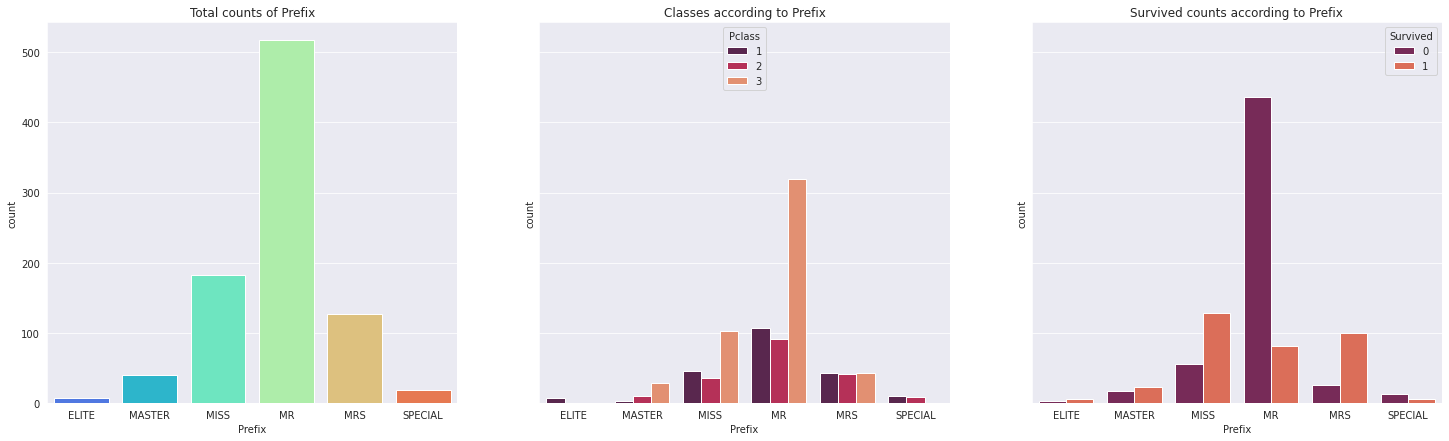

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(25,7), sharey=True)
sns.countplot(data=titanic[titanic.Survived!=2] ,x='Prefix' ,palette='rainbow',ax=ax[0]).set_title('Total counts of Prefix')
sns.countplot(data=titanic[titanic.Survived!=2] ,x='Prefix', hue='Pclass', palette='rocket', ax=ax[1]).set_title('Classes according to Prefix')
sns.countplot(data=titanic[titanic.Survived!=2] ,x='Prefix', hue='Survived', palette='rocket', ax=ax[2]).set_title('Survived counts according to Prefix')
plt.show()

> **Most men and Specials passengers didn't survive, but women, kids and elites survived (as always expected)**
>
> **Elite people are all at first class (as expected) and special people distributed between first and second class**
>
> **Most of elite  survived but most of specials didn't ... maybe they are old ages. we will see**

### Let's see families (why are families separated between spouses, siblings, parents and children?). Let's collect them all

In [19]:
titanic['Family'] = titanic.SibSp+titanic.Parch+1
titanic.drop(columns=['SibSp','Parch'], inplace=True)
titanic.Sex = titanic['Sex'].astype('category')
titanic.Sex = titanic.Sex.cat.codes
titanic

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,NaCount,Prefix,Family
PassengerId,,,,,,,,,,
1,0,3,1,22.0,A/5 21171,7.2500,S,1,MR,2
2,1,1,0,38.0,PC 17599,71.2833,C,0,MRS,2
3,1,3,0,26.0,STON/O2. 3101282,7.9250,S,1,MISS,1
4,1,1,0,35.0,113803,53.1000,S,0,MRS,2
5,0,3,1,35.0,373450,8.0500,S,1,MR,1
...,...,...,...,...,...,...,...,...,...,...
1305,2,3,1,NaN,A.5. 3236,8.0500,S,2,MR,1
1306,2,1,0,39.0,PC 17758,108.9000,C,0,ELITE,1
1307,2,3,1,38.5,SOTON/O.Q. 3101262,7.2500,S,1,MR,1


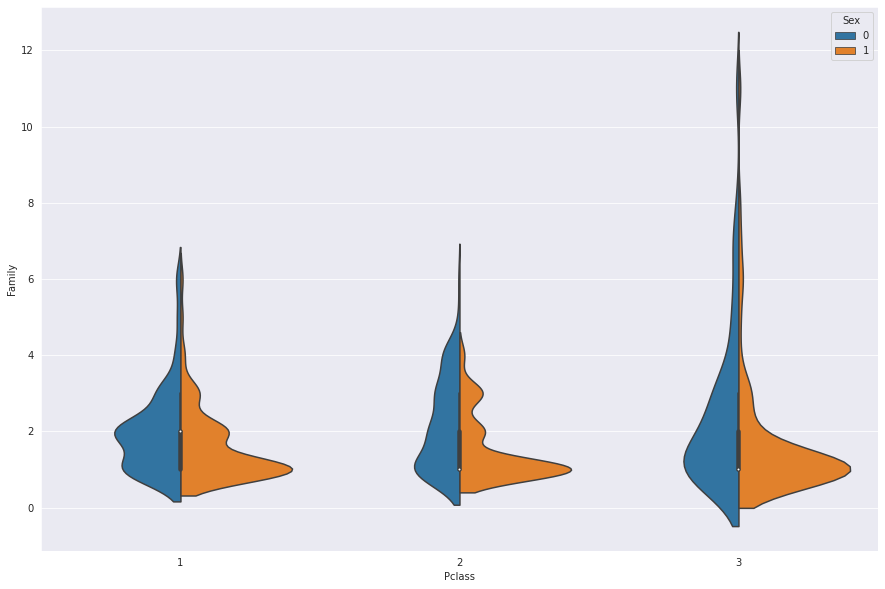

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,10))
sns.violinplot(data=titanic, x='Pclass', y='Family', hue='Sex', split=True, figsize=(10,5))
plt.show()

> **The 3rd class has bigger families than classes in the first and second.**
>
> **In all classes, families have more males than females. Will this affect the result?**

## What about fare cost. is this value for each person or what?

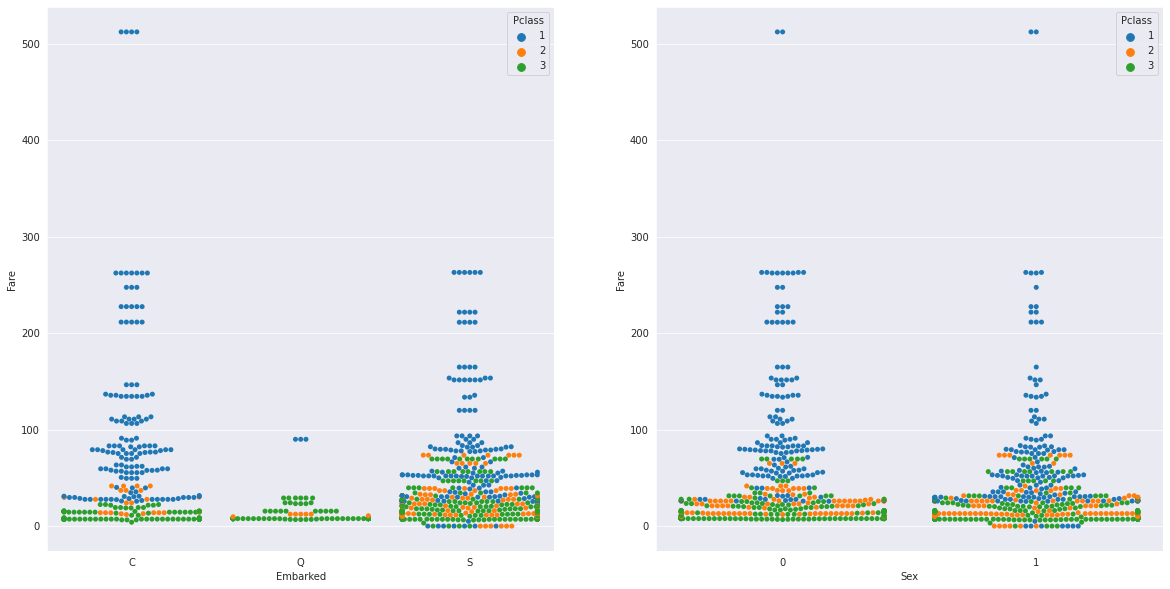

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(20,10))
sns.swarmplot(data=titanic, x='Embarked', y='Fare', hue='Pclass', ax=ax[0])
sns.swarmplot(data=titanic, x='Sex', y='Fare', hue='Pclass', ax=ax[1])
plt.show()

>**Tickets are supposed to be more expensive for higher classes, but they are not.**
>
>**Maybe this price is not for each person, but for all people on the same ticket. Let's check.**

In [22]:
maxFare = (titanic.groupby('Ticket')['Fare'].max()).to_frame(name='maxFare')
minFare = (titanic.groupby('Ticket')['Fare'].min()).to_frame(name='minFare')
tickets = pd.concat([maxFare,minFare], axis=1)
tickets[tickets.maxFare != tickets.minFare]

,maxFare,minFare
Ticket,,
3701,NaN,NaN
7534,9.8458,9.2167


> **Yes, fares is unified with the same ticket on all tickets (except two, that is. This mistake for sure).**
>
> **Let's compute the count of persons for each ticket, then calculate the share of each one.** 

In [23]:
titanic['TicketPersons'] = titanic.Ticket.apply(lambda x : titanic[titanic.Ticket== x].count()[0])
titanic['PersonFare'] = round(titanic.Fare/titanic.TicketPersons,2)

titanic.PersonFare.fillna(titanic[titanic.Pclass==3].PersonFare.mean(),inplace=True)
titanic.drop(columns=['Fare','Ticket'], inplace=True)
titanic

,Survived,Pclass,Sex,Age,Embarked,NaCount,Prefix,Family,TicketPersons,PersonFare
PassengerId,,,,,,,,,,
1,0,3,1,22.0,S,1,MR,2,1,7.25
2,1,1,0,38.0,C,0,MRS,2,2,35.64
3,1,3,0,26.0,S,1,MISS,1,1,7.92
4,1,1,0,35.0,S,0,MRS,2,2,26.55
5,0,3,1,35.0,S,1,MR,1,1,8.05
...,...,...,...,...,...,...,...,...,...,...
1305,2,3,1,NaN,S,2,MR,1,1,8.05
1306,2,1,0,39.0,C,0,ELITE,1,3,36.30
1307,2,3,1,38.5,S,1,MR,1,1,7.25


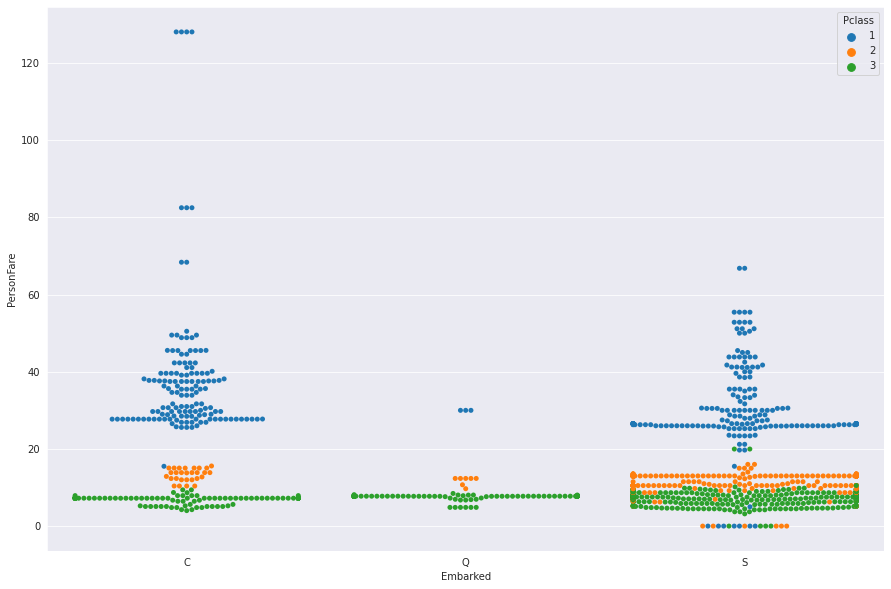

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,10))
sns.swarmplot(data=titanic, x='Embarked', y='PersonFare', hue='Pclass')
plt.show()

> **Now ticket prices have become reasonable, except a few free tickets. Maybe they were presents.**
>
> **Now there is a new question. Is family size supposed to be the same as "TicketPersons"?**
>
> **If this happens, I prefer to drop one of these features.**

In [25]:
titanic[titanic.Family != titanic.TicketPersons]

,Survived,Pclass,Sex,Age,Embarked,NaCount,Prefix,Family,TicketPersons,PersonFare
PassengerId,,,,,,,,,,
1,0,3,1,22.0,S,1,MR,2,1,7.25
7,0,1,1,54.0,S,0,MR,1,2,25.93
21,0,2,1,35.0,S,1,MR,1,2,13.00
32,1,1,0,NaN,C,1,MRS,2,3,48.84
39,0,3,0,18.0,S,1,MISS,3,2,9.00
...,...,...,...,...,...,...,...,...,...,...
1296,2,1,1,43.0,C,0,MR,2,1,27.72
1298,2,2,1,23.0,S,1,MR,2,1,10.50
1299,2,1,1,50.0,C,0,MR,3,5,42.30


> **there is 284 record has unmatching between family size and ticket person, and 1025 record are matching**
>
> **My opinion is that some families split into 2 or more tickets, and some other families pay for others (maids or friends) and include them on the same ticket.**
>
> **So, let's keep both two features for now, till the next visualizations will tell us what to do.**

### Age null values

> **Age still has 263 null values, but fortunately we have an indicator for age, which is the "Prefix". Let's see.**

In [26]:
age_nulls = titanic[titanic.Age.isna()].groupby(['Prefix'])['Survived'].count()
age_nulls

Prefix
ELITE        0
MASTER       8
MISS        51
MR         176
MRS         27
SPECIAL      1
Name: Survived, dtype: int64

In [27]:
avg_age = dict(round(titanic.groupby(['Prefix'])['Age'].mean(),2))
avg_ageS = pd.Series(avg_age, name='AVG')
avg_ageS

ELITE      36.88
MASTER      5.48
MISS       21.80
MR         32.25
MRS        36.92
SPECIAL    46.27
Name: AVG, dtype: float64

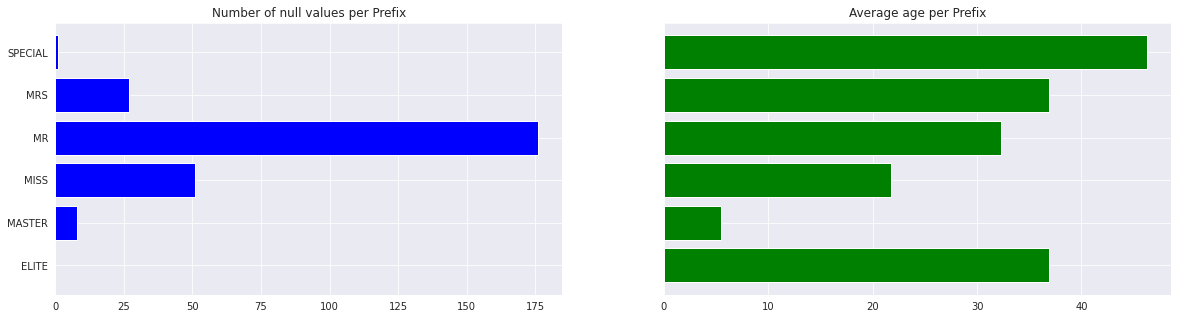

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2,sharey=True, figsize= (20,5))
ax[0].barh(age_nulls.index, age_nulls, color='b')
ax[0].set_title('Number of null values per Prefix')
ax[1].barh(avg_ageS.index, avg_ageS, color='g')
ax[1].set_title('Average age per Prefix')
plt.show()

In [29]:
for i in avg_age:
    titanic['Age'].loc[(titanic.Prefix==i) & (titanic.Age.isna())]=avg_age[i]

> **Finally, there are no missing values now. Let's encode the last two categories (embarked, Prefix). "They are nominal data".**

In [30]:
titanic = pd.get_dummies(data=titanic, columns=['Embarked', 'Prefix'], drop_first=False)
titanic

,Survived,Pclass,Sex,Age,NaCount,Family,TicketPersons,PersonFare,Embarked_C,Embarked_Q,Embarked_S,Prefix_ELITE,Prefix_MASTER,Prefix_MISS,Prefix_MR,Prefix_MRS,Prefix_SPECIAL
PassengerId,,,,,,,,,,,,,,,,,
1,0,3,1,22.00,1,2,1,7.25,0,0,1,0,0,0,1,0,0
2,1,1,0,38.00,0,2,2,35.64,1,0,0,0,0,0,0,1,0
3,1,3,0,26.00,1,1,1,7.92,0,0,1,0,0,1,0,0,0
4,1,1,0,35.00,0,2,2,26.55,0,0,1,0,0,0,0,1,0
5,0,3,1,35.00,1,1,1,8.05,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,3,1,32.25,2,1,1,8.05,0,0,1,0,0,0,1,0,0
1306,2,1,0,39.00,0,1,3,36.30,1,0,0,1,0,0,0,0,0
1307,2,3,1,38.50,1,1,1,7.25,0,0,1,0,0,0,1,0,0


> **I choose not to drop any dummy features now, but after then the correlation matrix will determine which one is better to remove.**

In [31]:
titanic.describe()

,Survived,Pclass,Sex,Age,NaCount,Family,TicketPersons,PersonFare,Embarked_C,Embarked_Q,Embarked_S,Prefix_ELITE,Prefix_MASTER,Prefix_MISS,Prefix_MR,Prefix_MRS,Prefix_SPECIAL
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.899924,2.294882,0.644003,29.893369,0.977846,1.883881,2.101604,14.751894,0.206264,0.093965,0.699771,0.006112,0.046600,0.200153,0.578304,0.151261,0.017571
std,0.853975,0.837836,0.478997,13.196501,0.624645,1.583639,1.779832,13.551847,0.404777,0.291891,0.458533,0.077967,0.210862,0.400267,0.494019,0.358440,0.131435
min,0.000000,1.000000,0.000000,0.170000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,21.800000,1.000000,1.000000,1.000000,7.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,1.000000,30.000000,1.000000,1.000000,1.000000,8.050000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2.000000,3.000000,1.000000,36.000000,1.000000,2.000000,3.000000,15.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.000000,3.000000,1.000000,80.000000,2.000000,11.000000,11.000000,128.080000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


> **Now, all our data is complete, numerical and clean. Let's make some visualizations before prepossessing and modeling.**

# Corelation Matrix

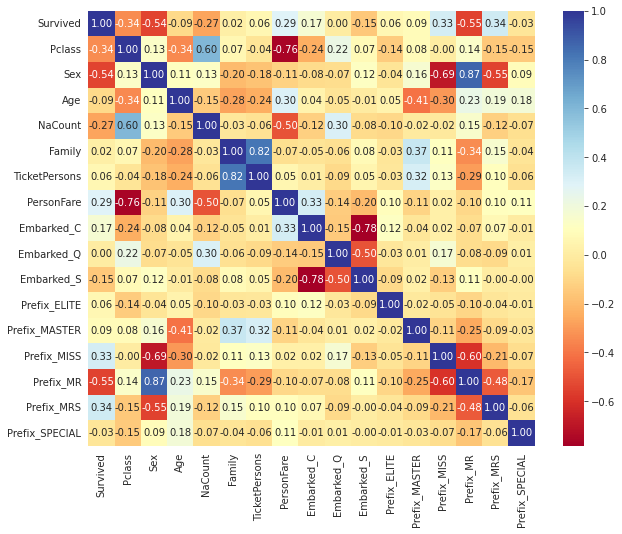

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10,8))
sns.heatmap(titanic[titanic.Survived!=2].corr(), cmap="RdYlBu", annot=True, fmt=".02f")
plt.show()

> **the best feature to remove is (Embarked_C, Prefix_MR, Family, Pclass), and no need to remove any other feature**

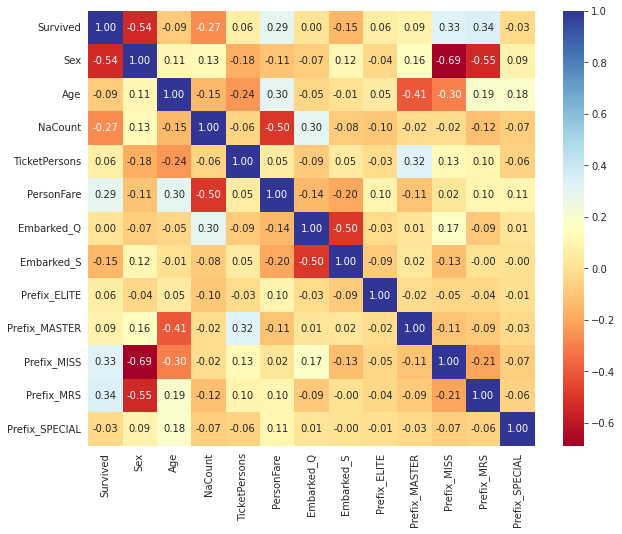

In [33]:
titanicdf = titanic.drop(columns=['Embarked_C', 'Prefix_MR','Family','Pclass'])
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10,8))
sns.heatmap(titanicdf[titanicdf.Survived!=2].corr(), cmap="RdYlBu", annot=True, fmt=".02f")
plt.show()

# preprocessing & Modeling

In [34]:
titanicX = titanicdf[titanicdf.Survived!=2]
titanicTest = titanicdf[titanicdf.Survived==2]
titanicY = titanicX.Survived
titanicX.drop(columns=['Survived'], inplace=True)
titanicTest.drop(columns=['Survived'], inplace=True)
# titanicX

In [35]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, MaxAbsScaler, PowerTransformer
scaler = PowerTransformer().fit(titanicX)
titanicX = scaler.transform(titanicX)
titanicTest = scaler.transform(titanicTest)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
xtrain, xvalid, ytrain, yvalid = train_test_split(titanicX, titanicY, test_size=.3, shuffle=True, random_state=10)

In [37]:
from sklearn.svm import SVC
svc_model = SVC(kernel='poly', degree=1)
svc_model.fit(xtrain,ytrain)
yvpred = svc_model.predict(xvalid)
ytpred = svc_model.predict(titanicTest)

In [38]:
print('Classification Report'.center(70,'-'), '\n')
print(classification_report(yvalid,yvpred))    
print('-'*70,'\n')
print(f'The accurecy of validation data is {round(accuracy_score(yvalid,yvpred)*100,2)}%')   
print('='*70,'\n')
print(' Test Result '.center(70,'-'), '\n')
print(confusion_matrix(titanic_Ytest,ytpred), '\n')
print(f'The accurecy of test data is {round(accuracy_score(titanic_Ytest,ytpred)*100,2)}%')

------------------------Classification Report------------------------- 

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       174
           1       0.74      0.69      0.71        94

    accuracy                           0.81       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.80      0.81      0.80       268

---------------------------------------------------------------------- 

The accurecy of validation data is 80.6%

---------------------------- Test Result ----------------------------- 

[[266   0]
 [  0 152]] 

The accurecy of test data is 100.0%


In [39]:
ytpred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [40]:
SVC_submit = pd.DataFrame({'PassengerId':titanic_test.index, 'Survived':ytpred})
SVC_submit.to_csv('submission.csv',index=False)
SVC_submit

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
